In [1]:
import os
import numpy as np

# WSe2 export 파일 확인
for f in os.listdir('.'):
    if f.endswith('.txt'):
        size = os.path.getsize(f) / 1024 / 1024
        print(f'{f}: {size:.1f} MB')

1 Export File (Header).txt: 0.0 MB
1 Export File (X-Axis).txt: 0.0 MB
1 Export File (Y-Axis).txt: 136.7 MB
MoSe2 PL data 1.txt: 0.0 MB


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 설정 — WSe2 중앙 crop
MAP_X = 60
SPEC_POINTS = 1024
row_start, row_end = 15, 45   # 중앙 30행
col_start, col_end = 15, 45   # 중앙 30열

# X축 읽기
x_axis = np.loadtxt('1 Export File (X-Axis).txt')
print(f'X축: {x_axis.min():.1f} ~ {x_axis.max():.1f} meV')

# Y축 읽기
print('데이터 읽는 중...')
spectra = []
with open('1 Export File (Y-Axis).txt', 'r') as f:
    for row in range(row_end):
        for col in range(MAP_X):
            spectrum = []
            for k in range(SPEC_POINTS):
                line = f.readline()
                if not line:
                    break
                spectrum.append(float(line.strip()))
            if len(spectrum) == SPEC_POINTS:
                if row >= row_start and col_start <= col < col_end:
                    spectra.append(spectrum)

spectra = np.array(spectra)
print(f'shape: {spectra.shape}')
print(f'강도 범위: {spectra.min():.1f} ~ {spectra.max():.1f}')
print('완료!')

X축: 677.2 ~ 960.0 meV
데이터 읽는 중...
shape: (900, 1024)
강도 범위: -31.5 ~ 6103.6
완료!


In [5]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 라인 정규화
baseline = np.percentile(spectra, 10, axis=1, keepdims=True)
spectra_sub = spectra - baseline
spectra_2d = spectra_sub.reshape(30, 30, 1024)
row_means = spectra_2d.mean(axis=(1, 2), keepdims=True)
global_mean = spectra_2d.mean()
spectra_norm = spectra_2d * (global_mean / (row_means + 1e-10))
spectra_norm = spectra_norm.reshape(900, 1024)
print('라인 정규화 완료!')

# Cosmic ray 제거 함수
def remove_cosmic_ray(s, threshold=5):
    med = np.median(s)
    std = np.std(s)
    mask = s > med + threshold * std
    sc = s.copy()
    for i in np.where(mask)[0]:
        if 0 < i < len(sc)-1:
            sc[i] = (sc[i-1] + sc[i+1]) / 2
    return sc

# 피크 추출
peak_positions = np.zeros((30, 30))
peak_intensities = np.zeros((30, 30))
fwhm_map = np.zeros((30, 30))

for idx in range(900):
    row = idx // 30
    col = idx % 30
    spec = spectra_norm[idx]
    spec_clean = remove_cosmic_ray(spec)
    spec_smooth = savgol_filter(spec_clean, 15, 3)
    peaks, _ = find_peaks(spec_smooth,
                          height=spec_smooth.max()*0.3,
                          prominence=5)
    if len(peaks) > 0:
        main_peak = peaks[np.argmax(spec_smooth[peaks])]
        peak_positions[row, col] = x_axis[main_peak]
        peak_intensities[row, col] = spec_smooth[main_peak]
        half_max = spec_smooth[main_peak] / 2
        left_idx = (np.abs(spec_smooth[:main_peak] - half_max)).argmin()
        right_idx = (np.abs(spec_smooth[main_peak:] - half_max)).argmin()
        fwhm_map[row, col] = abs(x_axis[main_peak+right_idx] - x_axis[left_idx])

print('피크 추출 완료!')
print(f'Peak position: {peak_positions[peak_positions>0].min():.1f} ~ {peak_positions.max():.1f} meV')
print(f'Peak intensity: {peak_intensities[peak_intensities>0].min():.1f} ~ {peak_intensities.max():.1f}')
print(f'FWHM: {fwhm_map[fwhm_map>0].min():.1f} ~ {fwhm_map.max():.1f} meV')

# K-means
features = np.stack([
    peak_positions.flatten(),
    peak_intensities.flatten(),
    fwhm_map.flatten()
], axis=1)
valid_mask = peak_positions.flatten() > 0
features_valid = features[valid_mask]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_valid)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(features_scaled)
cluster_map = np.zeros(900)
cluster_map[valid_mask] = labels + 1
cluster_map = cluster_map.reshape(30, 30)
print('K-means 완료!')
for i in range(1, 4):
    print(f'  Cluster {i}: {(cluster_map==i).sum()}개 픽셀')

라인 정규화 완료!
피크 추출 완료!
Peak position: 682.3 ~ 931.0 meV
Peak intensity: 21.7 ~ 1007.3
FWHM: 2.2 ~ 174.3 meV
K-means 완료!
  Cluster 1: 186개 픽셀
  Cluster 2: 713개 픽셀
  Cluster 3: 1개 픽셀


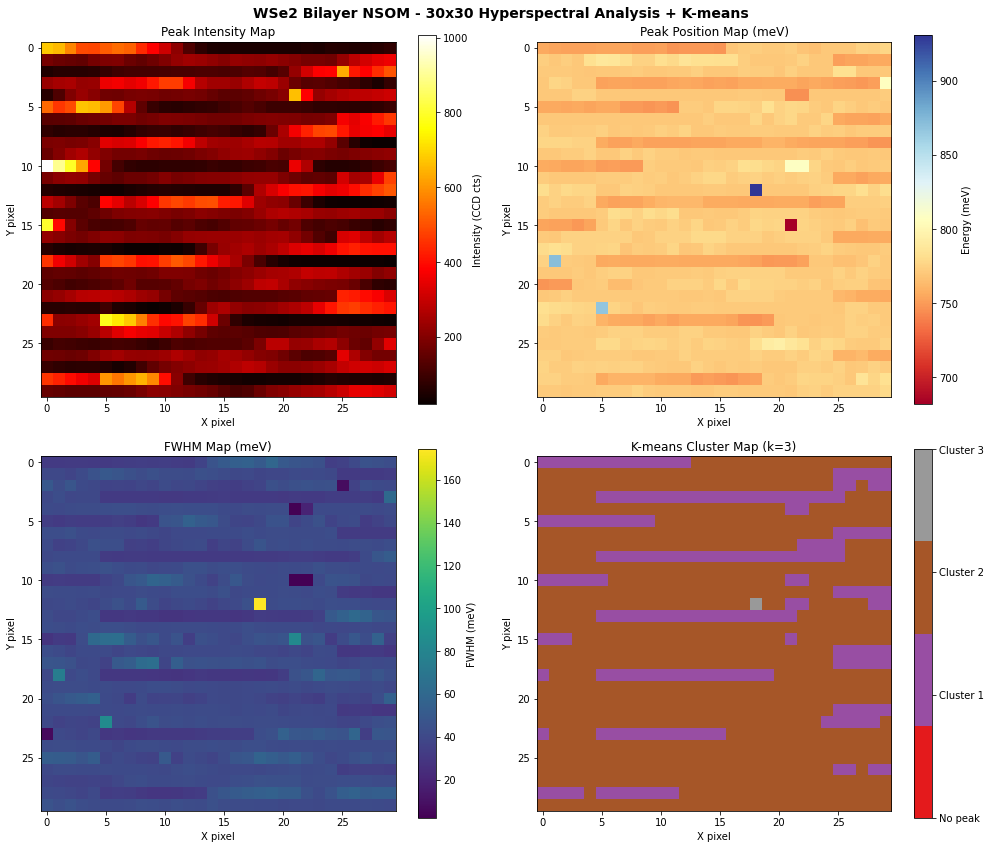

완료!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

im1 = axes[0,0].imshow(peak_intensities, cmap='hot', origin='upper')
axes[0,0].set_title('Peak Intensity Map', fontsize=12)
axes[0,0].set_xlabel('X pixel')
axes[0,0].set_ylabel('Y pixel')
plt.colorbar(im1, ax=axes[0,0], label='Intensity (CCD cts)')

im2 = axes[0,1].imshow(peak_positions, cmap='RdYlBu', origin='upper')
axes[0,1].set_title('Peak Position Map (meV)', fontsize=12)
axes[0,1].set_xlabel('X pixel')
axes[0,1].set_ylabel('Y pixel')
plt.colorbar(im2, ax=axes[0,1], label='Energy (meV)')

im3 = axes[1,0].imshow(fwhm_map, cmap='viridis', origin='upper')
axes[1,0].set_title('FWHM Map (meV)', fontsize=12)
axes[1,0].set_xlabel('X pixel')
axes[1,0].set_ylabel('Y pixel')
plt.colorbar(im3, ax=axes[1,0], label='FWHM (meV)')

cmap_cluster = plt.cm.get_cmap('Set1', 4)
im4 = axes[1,1].imshow(cluster_map, cmap=cmap_cluster,
                        origin='upper', vmin=0, vmax=3)
axes[1,1].set_title('K-means Cluster Map (k=3)', fontsize=12)
axes[1,1].set_xlabel('X pixel')
axes[1,1].set_ylabel('Y pixel')
cbar = plt.colorbar(im4, ax=axes[1,1], ticks=[0,1,2,3])
cbar.set_ticklabels(['No peak', 'Cluster 1', 'Cluster 2', 'Cluster 3'])

plt.suptitle('WSe2 Bilayer NSOM - 30x30 Hyperspectral Analysis + K-means',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('WSe2_bilayer_kmeans.png', dpi=150)
plt.show()
print('완료!')